# **Project Title**: Identifying Early Signs of U.S. Economic Recessions Using Historical Data
**Group ID**: 5

**Members**: May Sabai, Emily Lu

Quantitatively compares current economic indicator trends against
pre-recession periods for all historical U.S. recessions.

Methods:

1. Pearson correlation  – direction agreement (-1 to +1)
2. DTW distance         – shape similarity (lower = more similar)
3. A composite similarity score (0-100, higher = more similar)

The composite score is used to rank recessions by closeness to current data.

**Reference Period**: April 2024 – March 2026

**Indicators Analysed**: Unemployment, Interest Rate, Oil, SP500, VIX, Gold

**Recessions Compared**: 8 historical U.S. recessions (1969–2020)

In [41]:
# install libraries from Yahoo Finance Data
!pip install yfinance fredapi

In [42]:
!pip install dtaidistance

In [43]:
# import necessary libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from fredapi import Fred
import yfinance as yf
from scipy.stats import pearsonr
from dtaidistance import dtw  # Dynamic Time Warping

# 1. Configuration

**Economic recessions**

1. Dec 1969 – Nov 1970 (Vietnam War spending + Fed tightening to fight inflation)
2. Nov 1973 – Mar 1975 (Oil embargo (OPEC) → energy crisis and stagflation)
3. Jan 1980 – Jul 1980 (Fed sharply raised interest rates to control high inflation)
4. Jul 1981 – Nov 1982 (Continued high interest rates under Volcker crushed inflation but caused deep unemployment)
5. Jul 1990 – Mar 1991 (Gulf War oil shock + savings and loan crisis)
6. Mar 2001 – Nov 2001 (Dot-com bubble burst, tech layoffs, stock market crash)
7. Dec 2007 – Jun 2009 (Housing bubble collapse, banking crisis, Great Recession)
8. *Feb* 2020 – Apr 2020 (COVID-19 pandemic shutdowns, sudden job losses)

In [44]:
# API key from FRED to extract data
FRED_API_KEY = "65796ccf4eea28ff944ebb1cf7ea91de"

In [45]:
# Reference date: the last full month of "current" data we treat as T=0
# (one month before the most-recent month so data is fully settled)
CURRENT_END = "2026-03-31"

In [46]:
# Time windows to compare (months before recession start / months before CURRENT_END)
# key = label shown in output, value = number of months to look back
TIME_WINDOWS = {
    "1 Month":  1,
    "2 Months": 2,
    "3 Months": 3,
    "6 Months": 6,
    "1 Year":  12,
    "2 Years": 24,
}

In [47]:
# Recession definitions: name → start date of the recession
# (we compare the N months *before* this date)
RECESSIONS = {
    "1969 Vietnam/Fed Tightening":  "1969-12-01",
    "1973 Oil Embargo Stagflation": "1973-11-01",
    "1980 Volcker Inflation Fight":  "1980-01-01",
    "1981 High Interest Rates":     "1981-07-01",
    "1990 Gulf War Oil Shock":      "1990-07-01",
    "2001 Dot-Com Bust":            "2001-03-01",
    "2008 Great Recession":         "2007-12-01",  # housing peak was Dec 2007
    "2020 COVID Pandemic":          "2020-02-01",
}

In [48]:
# Indicators to fetch and compare
# key = column name used throughout, value = (source, ticker_or_series_id)
INDICATORS = {
    "Unemployment": ("fred", "UNRATE"),
    "Interest":     ("fred", "DFF"),
    "Oil":          ("fred", "DCOILWTICO"),
    "SP500":        ("yf",   "^GSPC"),
    "VIX":          ("yf",   "^VIX"),
    "Gold":         ("yf",   "^XAU"),
}

In [49]:
# Minimum similarity score threshold to flag as "notable match"
SIMILARITY_THRESHOLD = 60  # out of 100

# 2. Load the data

In [50]:
def load_all_data(fred_api_key: str) -> pd.DataFrame:
    """
    Pull all indicator series from FRED and Yahoo Finance,
    resample to monthly frequency, and merge into one DataFrame.

    Returns a monthly DataFrame indexed by date, columns = indicator names.
    """
    print("Loading data from FRED and Yahoo Finance …")
    fred = Fred(api_key=fred_api_key)

    monthly_series = []

    for col_name, (source, ticker) in INDICATORS.items():
        if source == "fred":
            raw = fred.get_series(ticker)
            s = raw.resample("ME").last().rename(col_name)
        else:  # Yahoo Finance
            raw = yf.download(ticker, start="1968-01-01", progress=False)["Close"]
            # yf sometimes returns a MultiIndex — flatten it
            if isinstance(raw, pd.DataFrame):
                raw = raw.squeeze()
            s = raw.resample("ME").last().rename(col_name)

        monthly_series.append(s)
        print(f"  ✓ {col_name}")

    df = pd.concat(monthly_series, axis=1)
    df = df.sort_index()
    print(f"  Data loaded: {df.index[0].date()} → {df.index[-1].date()}\n")
    return df

# 3. Window Extraction

In [51]:
def extract_window(df: pd.DataFrame, end_date: str, n_months: int) -> pd.DataFrame:
    """
    Return the n_months of data ending at end_date (inclusive).
    Returns an empty DataFrame if there isn't enough history.
    """
    end = pd.Timestamp(end_date)
    # Go back n_months from end_date
    start = end - pd.DateOffset(months=n_months)
    window = df.loc[start:end].copy()
    return window

# 4. Normalization

In [52]:
def normalise(series: pd.Series) -> pd.Series:
    """
    Min-max normalise a series to [0, 1] so that indicators with
    very different scales (e.g. Oil vs Unemployment %) can be compared.
    Returns a flat line of 0.5 if the range is zero (constant series).
    """
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

# 5. Similarity Metrics

In [53]:
def pearson_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """
    Pearson correlation rescaled from [-1,1] to [0,100].
    Values near 100 mean the two series move in exactly the same direction.
    Returns 50 (neutral) when one series is constant.
    """
    if len(a) < 3 or np.std(a) == 0 or np.std(b) == 0:
        return 50.0
    r, _ = pearsonr(a, b)
    # Map [-1, 1] → [0, 100]
    return (r + 1) / 2 * 100

In [54]:
def dtw_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """
    Dynamic Time Warping distance converted to a similarity score [0, 100].
    DTW handles slight phase shifts better than plain Euclidean distance.

    We normalise the raw DTW distance by the maximum possible distance
    (all-ones vs all-zeros for min-max scaled data) so results are comparable
    across different window lengths.
    """
    if len(a) < 2 or len(b) < 2:
        return 50.0

    # dtaidistance expects float64 arrays
    a64 = a.astype(np.float64)
    b64 = b.astype(np.float64)

    dist = dtw.distance_fast(a64, b64)

    # Maximum possible DTW distance for sequences of this length (all 0 vs all 1)
    max_dist = np.sqrt(len(a))  # rough upper bound for [0,1] normalised data

    similarity = max(0.0, (1 - dist / max_dist)) * 100
    return similarity

In [55]:
def composite_score(pearson_s: float, dtw_s: float,
                    pearson_weight: float = 0.5,
                    dtw_weight: float = 0.5) -> float:
    """
    Weighted average of Pearson and DTW similarity scores.
    Both weights default to 0.5 (equal importance).
    Adjust weights here if you want to emphasise direction vs shape.
    """
    return pearson_weight * pearson_s + dtw_weight * dtw_s

# 6. Core Comparison Engine

In [56]:
def compare_all(df: pd.DataFrame) -> pd.DataFrame:
    """
    Main loop: for every (recession × indicator × time-window) triple,
    compute Pearson similarity, DTW similarity, and composite score.

    Returns a long-form DataFrame with columns:
        Recession | Indicator | Window | Pearson | DTW | Score
    """
    results = []

    # ── Current data window (T = CURRENT_END going back N months) ──
    # We build current windows once per time-window length for efficiency
    current_windows = {}
    for window_label, n_months in TIME_WINDOWS.items():
        cw = extract_window(df, CURRENT_END, n_months)
        current_windows[window_label] = cw

    # ── Loop over all historical recessions ──
    for recession_name, recession_start in RECESSIONS.items():
        for window_label, n_months in TIME_WINDOWS.items():

            # Extract the same-length window ending just before the recession
            hist_window = extract_window(df, recession_start, n_months)
            curr_window = current_windows[window_label]

            # Skip if we don't have enough historical data
            if hist_window.empty or len(hist_window) < 2:
                continue

            for indicator in INDICATORS.keys():
                # Both windows must have data for this indicator
                if indicator not in hist_window.columns or indicator not in curr_window.columns:
                    continue

                hist_series = hist_window[indicator].dropna()
                curr_series = curr_window[indicator].dropna()

                # Need at least 2 data points to compute similarity
                if len(hist_series) < 2 or len(curr_series) < 2:
                    continue

                # Resample both to the same length using interpolation
                # (required because windows can differ by 1-2 months due to NaNs)
                target_len = min(len(hist_series), len(curr_series))
                h_resampled = np.interp(
                    np.linspace(0, 1, target_len),
                    np.linspace(0, 1, len(hist_series)),
                    hist_series.values
                )
                c_resampled = np.interp(
                    np.linspace(0, 1, target_len),
                    np.linspace(0, 1, len(curr_series)),
                    curr_series.values
                )

                # Normalise to [0,1] before computing DTW (makes distance scale-invariant)
                h_norm = normalise(pd.Series(h_resampled)).values
                c_norm = normalise(pd.Series(c_resampled)).values

                # Compute similarity metrics
                p_score = pearson_similarity(h_norm, c_norm)
                d_score = dtw_similarity(h_norm, c_norm)
                comp    = composite_score(p_score, d_score)

                results.append({
                    "Recession":  recession_name,
                    "Indicator":  indicator,
                    "Window":     window_label,
                    "Pearson":    round(p_score, 1),
                    "DTW":        round(d_score, 1),
                    "Score":      round(comp, 1),
                })

    return pd.DataFrame(results)

# 7. Summary and Ranking

In [57]:
def print_top_matches(results: pd.DataFrame):
    """
    Print the best-matching recession per indicator per time-window,
    and an overall ranking of which recession the current data
    most resembles across all windows.
    """
    print("\n" + "=" * 70)
    print("  RECESSION SIMILARITY REPORT")
    print("  (Score 0-100 — higher = current data looks more like pre-recession)")
    print("=" * 70)

    window_order = list(TIME_WINDOWS.keys())  # preserve chronological order

    # ── Per-indicator, per-window: who is the best match? ──
    for indicator in INDICATORS.keys():
        sub = results[results["Indicator"] == indicator]
        print(f"\n{'─'*60}")
        print(f"  INDICATOR: {indicator}")
        print(f"{'─'*60}")
        print(f"  {'Window':<12} {'Best Match Recession':<38} {'Score':>5}")
        print(f"  {'-'*12} {'-'*38} {'-'*5}")

        for window in window_order:
            w_sub = sub[sub["Window"] == window].sort_values("Score", ascending=False)
            if w_sub.empty:
                continue
            top = w_sub.iloc[0]
            flag = " ⚠️" if top["Score"] >= SIMILARITY_THRESHOLD else ""
            print(f"  {window:<12} {top['Recession']:<38} {top['Score']:>5.1f}{flag}")

    # ── Overall ranking across all indicators and windows ──
    print(f"\n{'=' * 70}")
    print("  OVERALL RANKING — Which recession does the current period resemble most?")
    print(f"  (average composite score across ALL indicators and ALL windows)")
    print(f"{'=' * 70}")

    overall = (
        results.groupby("Recession")["Score"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    overall.columns = ["Recession", "Avg Score"]

    for rank, row in overall.iterrows():
        bar = "█" * int(row["Avg Score"] / 5)  # simple ASCII bar (max 20 blocks)
        flag = " ⚠️  NOTABLE MATCH" if row["Avg Score"] >= SIMILARITY_THRESHOLD else ""
        print(f"  {rank+1}. {row['Recession']:<40} {row['Avg Score']:>5.1f}  {bar}{flag}")

    print()
    return overall

# 8. Visualization

In [58]:
def plot_heatmap(results: pd.DataFrame):
    """
    Heatmap: rows = recessions, columns = indicators,
    cell = average composite score across all time windows.
    """
    pivot = results.pivot_table(
        index="Recession", columns="Indicator", values="Score", aggfunc="mean"
    )
    # Sort recessions by overall average (best match at top)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",      # Red = low similarity, Green = high similarity
        vmin=0,
        vmax=100,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Composite Similarity Score (0–100)"}
    )
    ax.set_title(
        "Similarity of Current Economic Trend to Pre-Recession Periods\n"
        "(averaged across all time windows: 1M, 2M, 3M, 6M, 1Y, 2Y)",
        fontsize=13, pad=12
    )
    ax.set_xlabel("Economic Indicator")
    ax.set_ylabel("Recession")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

In [59]:
def plot_window_heatmap(results: pd.DataFrame):
    """
    Heatmap: rows = recessions, columns = time-windows,
    cell = average composite score across all indicators for that window.
    """
    pivot = results.pivot_table(
        index="Recession", columns="Window", values="Score", aggfunc="mean"
    )

    # Keep window columns in the correct chronological order
    ordered_cols = [w for w in TIME_WINDOWS.keys() if w in pivot.columns]
    pivot = pivot[ordered_cols]
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Composite Similarity Score (0–100)"}
    )
    ax.set_title(
        "Similarity of Current Trend to Pre-Recession Periods\n"
        "(averaged across all indicators, by time window)",
        fontsize=13, pad=12
    )
    ax.set_xlabel("Look-back Window")
    ax.set_ylabel("Recession")
    ax.tick_params(axis="x", rotation=15)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

In [62]:
def plot_overlay_per_indicator(df: pd.DataFrame, results: pd.DataFrame):
    window_label = "1 Year"
    n_months = TIME_WINDOWS[window_label]

    top_matches = (
        results[results["Window"] == window_label]
        .sort_values("Score", ascending=False)
        .groupby("Indicator")
        .head(2)
    )

    indicators = list(INDICATORS.keys())

    for indicator in indicators:
        fig, ax = plt.subplots(1, 1, figsize=(14, 5))

        # Current window (normalised)
        curr = extract_window(df, CURRENT_END, n_months)[indicator].dropna()
        curr_norm = normalise(curr)
        x_curr = np.linspace(-n_months, 0, len(curr_norm))
        ax.plot(x_curr, curr_norm.values, color="black", linewidth=2.5,
                label="Current (2024–2026)", zorder=5)

        # Plot top matches
        colors = ["#e41a1c", "#377eb8"]
        indicator_matches = top_matches[top_matches["Indicator"] == indicator]

        for i, (_, row) in enumerate(indicator_matches.iterrows()):
            recession_start = RECESSIONS[row["Recession"]]
            hist = extract_window(df, recession_start, n_months)[indicator].dropna()
            hist_norm = normalise(hist)
            x_hist = np.linspace(-n_months, 0, len(hist_norm))
            label = f"{row['Recession']} (score: {row['Score']:.0f})"
            ax.plot(x_hist, hist_norm.values, color=colors[i],
                    linewidth=1.8, linestyle="--", alpha=0.85, label=label)

        ax.set_title(
            f"{indicator} — Normalised Trend (1 Year Before Recession/Today)",
            fontsize=11
        )
        ax.set_xlabel("Months Before Recession Start / Today (0 = recession start / today)")
        ax.set_ylabel("Normalised Value [0–1]")
        ax.legend(fontsize=9, loc="upper left")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-n_months - 0.5, 0.5)

        plt.suptitle(
            "Current Indicator Trends vs Top 2 Best-Matching Pre-Recession Periods\n"
            "(1-Year Look-back Window, Min-Max Normalised)",
            fontsize=13
        )
        plt.tight_layout()
        plt.show()  # displays each indicator as a separate plot

In [61]:
def plot_overall_bar(overall: pd.DataFrame):
    """
    Horizontal bar chart of overall average similarity scores — quick visual ranking.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [
        "#d62728" if s >= SIMILARITY_THRESHOLD else "#aec7e8"
        for s in overall["Avg Score"]
    ]
    bars = ax.barh(overall["Recession"][::-1], overall["Avg Score"][::-1],
                   color=colors[::-1], edgecolor="white", linewidth=0.5)
    ax.set_xlabel("Average Composite Similarity Score (0–100)")
    ax.set_title(
        "Overall Recession Similarity to Current Economic Trend\n"
        "(averaged across all indicators and all time windows)",
        fontsize=12
    )
    ax.set_xlim(0, 105)
    ax.axvline(SIMILARITY_THRESHOLD, color="red", linestyle="--",
               alpha=0.7, label=f"Notable-match threshold ({SIMILARITY_THRESHOLD})")
    ax.legend(fontsize=9)

    # Annotate bars with the score
    for bar, score in zip(bars, overall["Avg Score"][::-1]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f"{score:.1f}", va="center", fontsize=9)

    patch_high = mpatches.Patch(color="#d62728", label=f"Score ≥ {SIMILARITY_THRESHOLD} (notable)")
    patch_low  = mpatches.Patch(color="#aec7e8", label=f"Score < {SIMILARITY_THRESHOLD}")
    ax.legend(handles=[patch_high, patch_low], fontsize=9, loc="lower right")

    plt.tight_layout()
    plt.show()

# 9.  ENTRY POINT

Loading data from FRED and Yahoo Finance …
  ✓ Unemployment
  ✓ Interest
  ✓ Oil
  ✓ SP500
  ✓ VIX
  ✓ Gold
  Data loaded: 1948-01-31 → 2026-04-30

Computing similarity scores …
  ✓ 180 (recession × indicator × window) comparisons completed.


  RECESSION SIMILARITY REPORT
  (Score 0-100 — higher = current data looks more like pre-recession)

────────────────────────────────────────────────────────────
  INDICATOR: Unemployment
────────────────────────────────────────────────────────────
  Window       Best Match Recession                   Score
  ------------ -------------------------------------- -----
  2 Months     1981 High Interest Rates                75.0 ⚠️
  3 Months     1969 Vietnam/Fed Tightening             82.2 ⚠️
  6 Months     1973 Oil Embargo Stagflation            77.6 ⚠️
  1 Year       2008 Great Recession                    78.3 ⚠️
  2 Years      1981 High Interest Rates                84.0 ⚠️

────────────────────────────────────────────────────────────
  INDICATO

,Recession,Indicator,Window,Pearson,DTW,Score
0,2020 COVID Pandemic,Interest,1 Year,99.4,93.0,96.2
1,1990 Gulf War Oil Shock,Gold,3 Months,99.5,92.5,96.0
2,2008 Great Recession,SP500,3 Months,99.2,90.5,94.9
3,2020 COVID Pandemic,VIX,3 Months,99.1,90.0,94.6
4,2001 Dot-Com Bust,SP500,3 Months,98.9,88.7,93.8
5,2008 Great Recession,Interest,6 Months,96.3,90.9,93.6
6,2008 Great Recession,SP500,2 Years,93.3,92.5,92.9
7,1981 High Interest Rates,SP500,3 Months,98.0,87.5,92.8
8,2020 COVID Pandemic,Interest,6 Months,97.2,87.7,92.5
9,2008 Great Recession,Gold,6 Months,95.9,88.5,92.2



Generating plots …


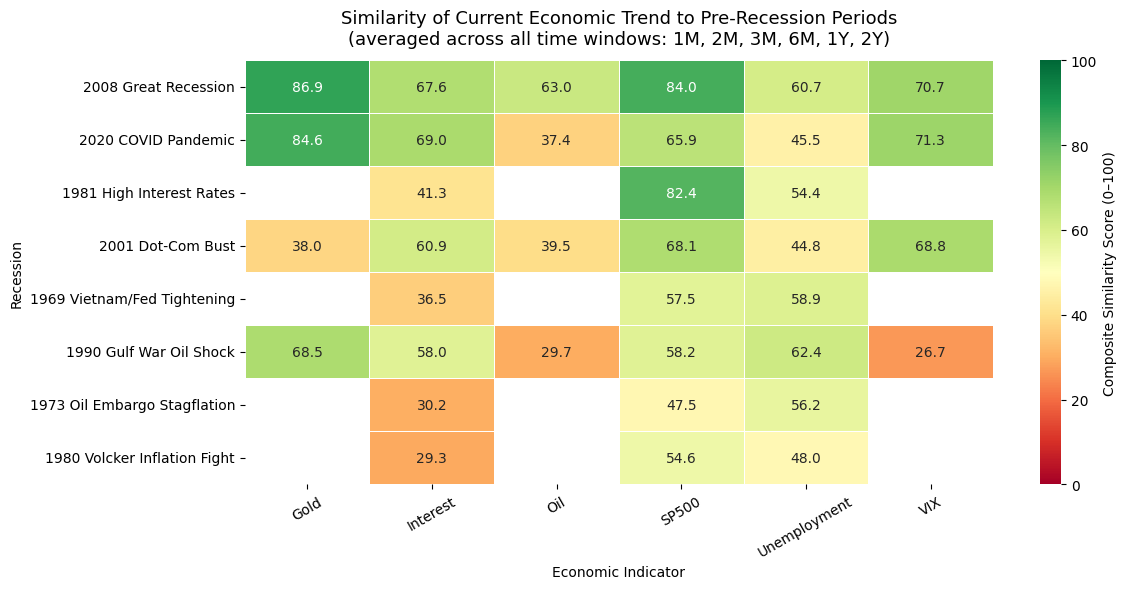

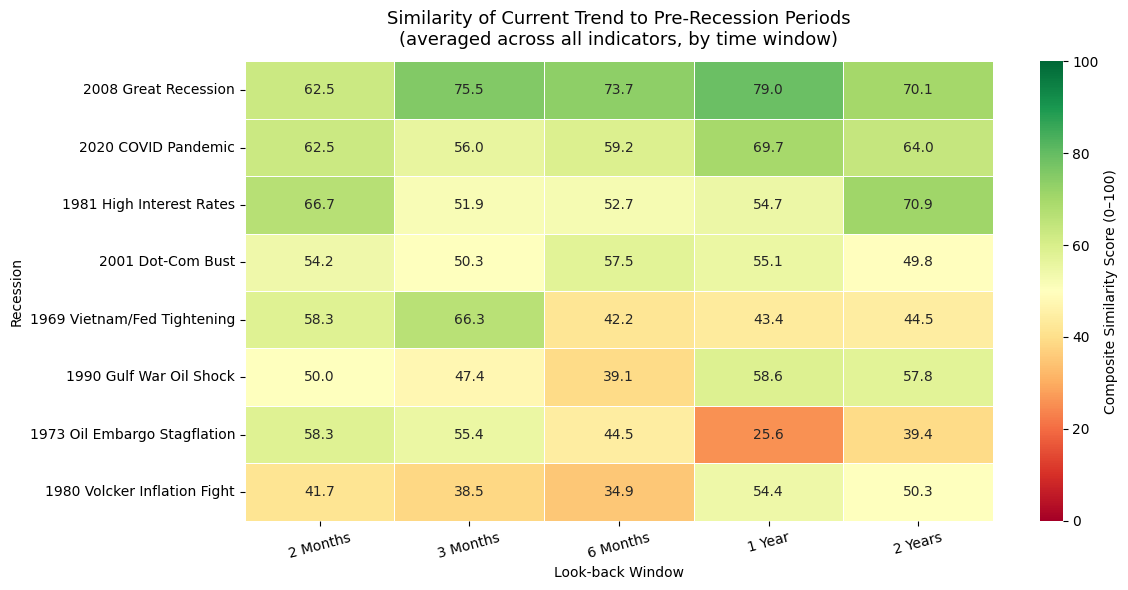

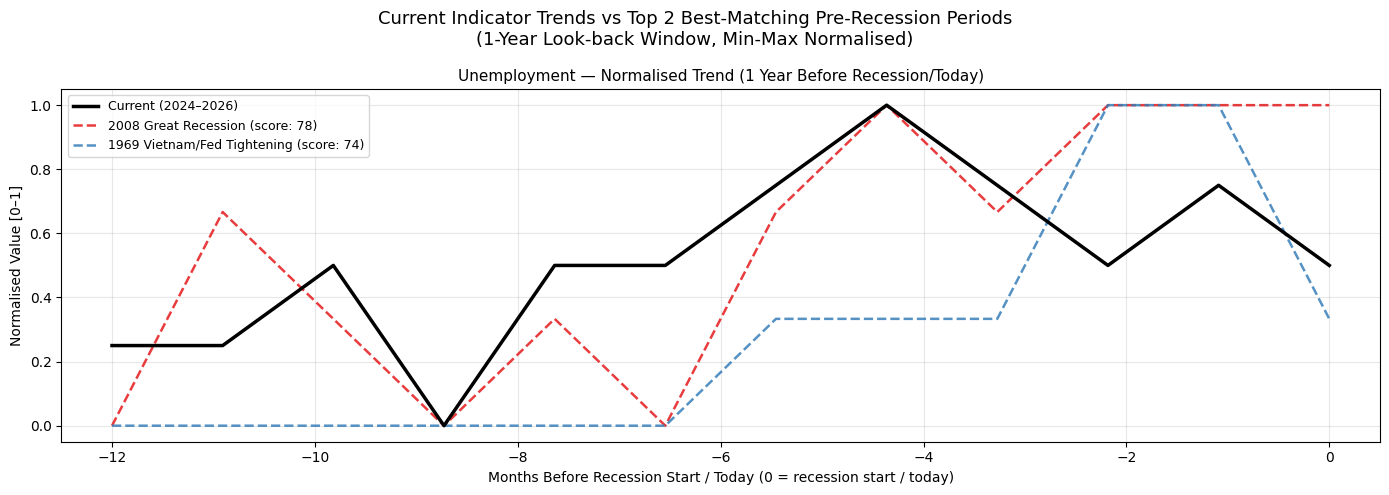

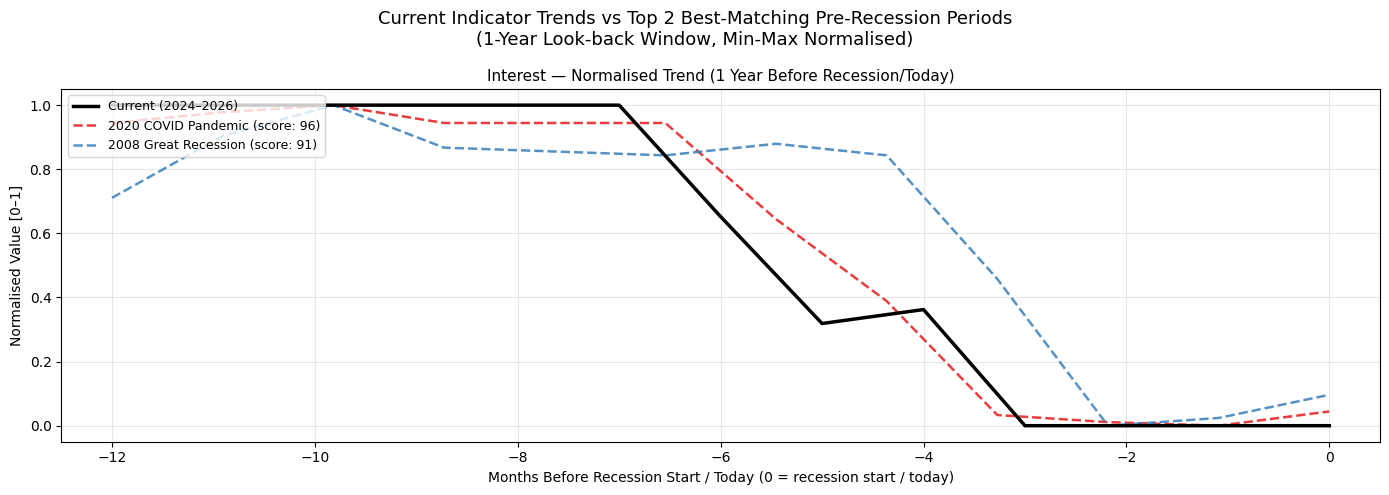

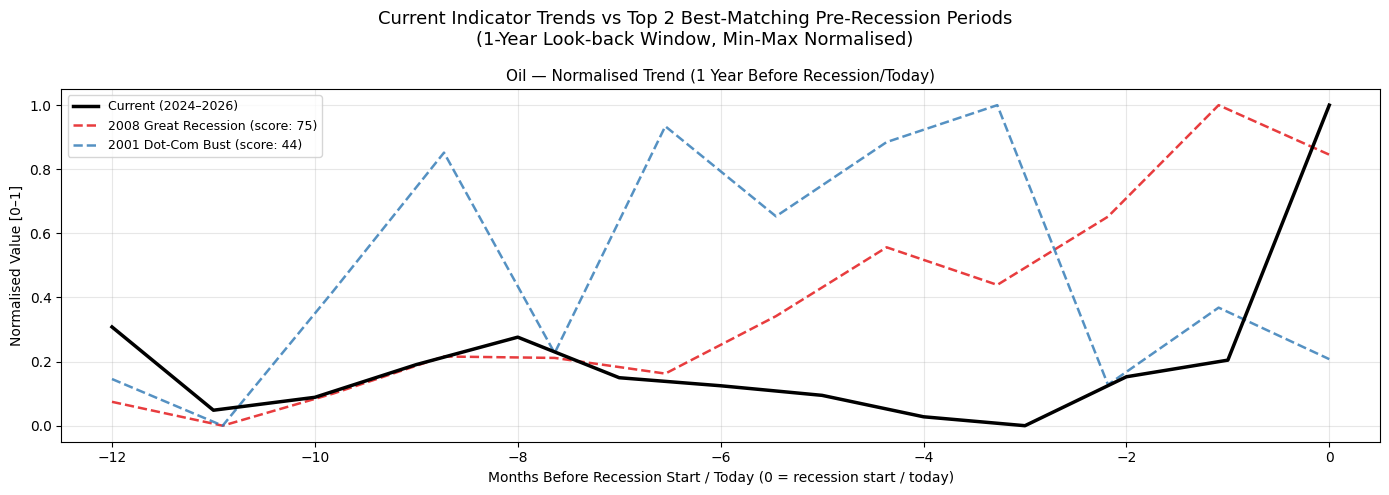

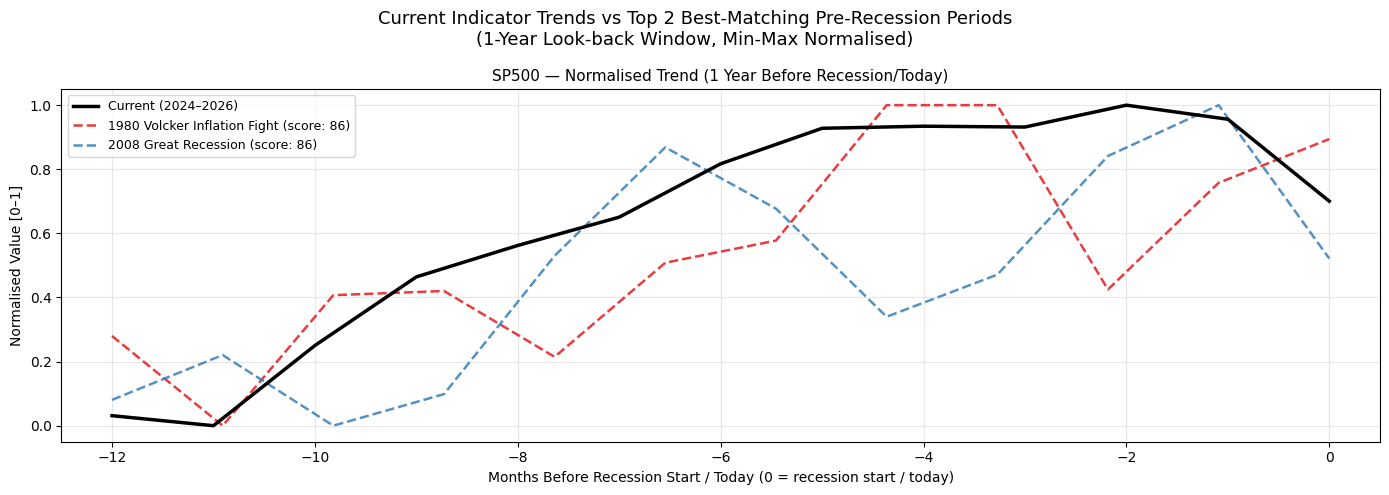

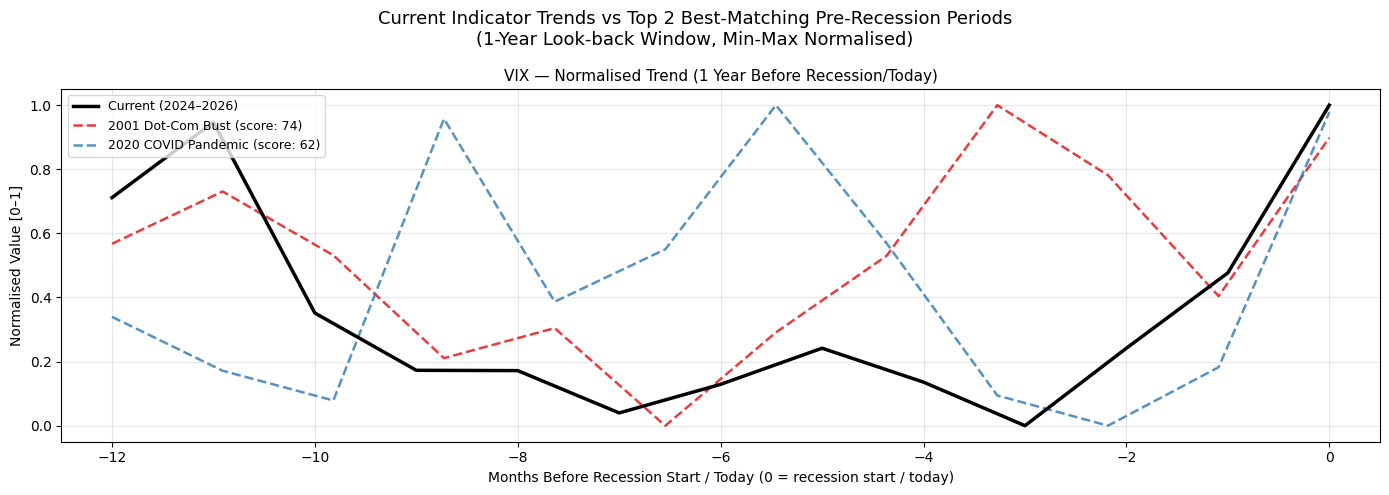

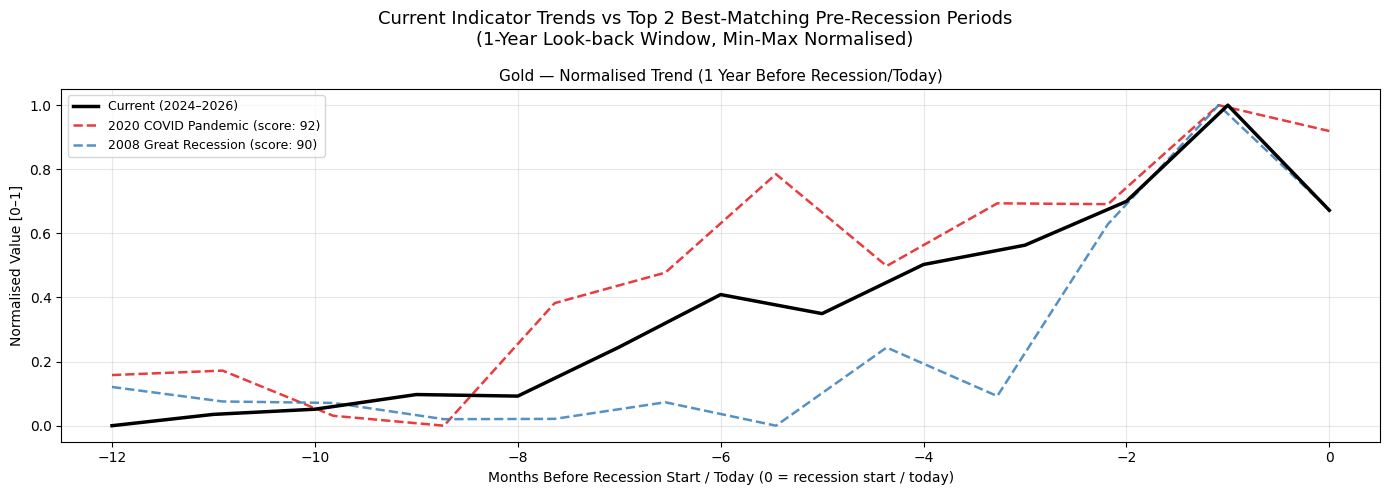

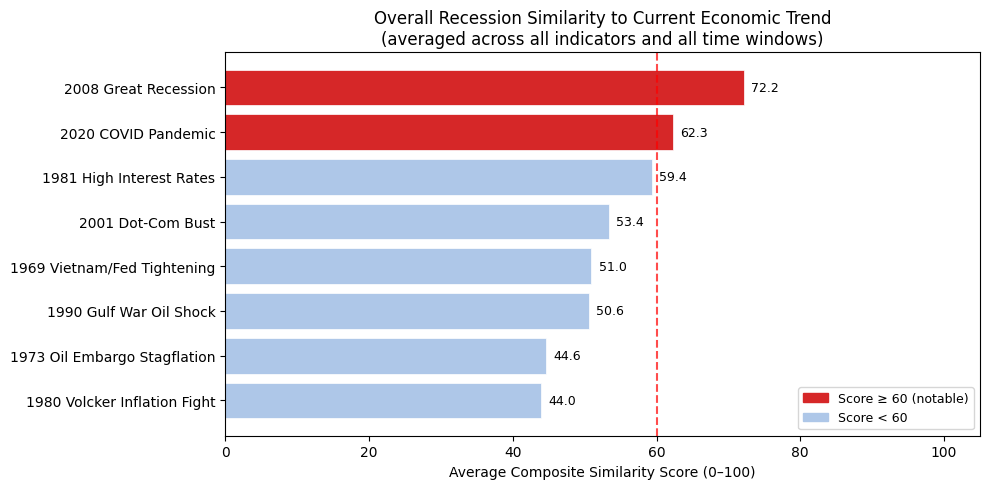


Analysis complete.


In [63]:
if __name__ == "__main__":

    # Step 1: Load all data once
    df = load_all_data(FRED_API_KEY)

    # Step 2: Run the comparison engine
    print("Computing similarity scores …")
    results = compare_all(df)
    print(f"  ✓ {len(results)} (recession × indicator × window) comparisons completed.\n")

    # Step 3: Print the ranked summary to console
    overall = print_top_matches(results)

    # Step 4: Display the full results table inline (sorted by score descending)
    print("\n── Full Results Table (top 30 rows by Score) ──")
    display_df = results.sort_values("Score", ascending=False).reset_index(drop=True)
    try:
        from IPython.display import display
        display(display_df.head(30))
    except ImportError:
        print(display_df.head(30).to_string(index=False))

    # Step 5: Generate visualisations
    print("\nGenerating plots …")
    plot_heatmap(results)
    plot_window_heatmap(results)
    plot_overlay_per_indicator(df, results)
    plot_overall_bar(overall)

    print("\nAnalysis complete.")